In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import utm

In [24]:
%pip install utm

Note: you may need to restart the kernel to use updated packages.


In [25]:
df_raw = pd.read_csv('Divar.csv', low_memory=False)
print("raw:", df_raw.shape)

# محدود کردن به آگهی‌های فروش (چون فقط برای این دسته قیمت قابل تحلیل داریم)
df_raw = df_raw[df_raw['cat2_slug'].isin(['residential-sell', 'commercial-sell'])].copy()
print("after category filter:", df_raw.shape)

# توجه: ستون transformable_price برای هیچ آگهی فروشی مقدار ندارد (باگ/نقص در دیتاست)
# بنابراین به‌جای آن از price_value (قیمت خام فروش) استفاده می‌کنیم
features = ['price_value', 'building_size', 'location_latitude', 'location_longitude']

for col in features:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

df_clean = df_raw.dropna(subset=features).copy()
print("after dropna:", df_clean.shape)

def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    print(f"{column}: bounds=({lower_bound:.2f}, {upper_bound:.2f})")
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

df_ml = remove_outliers_iqr(df_clean, 'price_value')
print("after price outlier removal:", df_ml.shape)

df_ml = remove_outliers_iqr(df_ml, 'building_size')
print("after size outlier removal:", df_ml.shape)

easting, northing, _, _ = utm.from_latlon(
    df_ml['location_latitude'].values,
    df_ml['location_longitude'].values
)
df_ml['UTM_X'] = easting
df_ml['UTM_Y'] = northing

print("final df_ml:", df_ml.shape)
df_ml[['UTM_X', 'UTM_Y', 'price_value']].describe()

raw: (1000000, 61)
after category filter: (597569, 61)
after dropna: (371344, 61)
price_value: bounds=(-5300000000.00, 12780000000.00)
after price outlier removal: (335796, 61)
building_size: bounds=(-57.00, 295.00)
after size outlier removal: (297297, 61)
final df_ml: (297297, 63)


,UTM_X,UTM_Y,price_value
count,2.972970e+05,2.972970e+05,2.972970e+05
mean,5.531452e+05,3.886115e+06,3.439616e+09
std,2.859497e+05,2.549719e+05,2.746749e+09
min,-1.651659e+05,2.614585e+06,0.000000e+00
25%,4.639828e+05,3.836911e+06,1.450000e+09
50%,5.276502e+05,3.952338e+06,2.650000e+09
75%,5.758832e+05,4.044087e+06,4.680000e+09
max,1.661360e+06,4.477524e+06,1.278000e+10


In [26]:
dbscan_features = ['UTM_X', 'UTM_Y', 'price_value']

# نمونه‌گیری تصادفی برای کاهش هزینه‌ی محاسباتی DBSCAN
sample_df = df_ml.sample(n=min(50000, len(df_ml)), random_state=42).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(sample_df[dbscan_features])

print(X_scaled.shape)
print(X_scaled[:5])

(50000, 3)
[[ 2.48143009  0.66155988 -0.55167462]
 [-1.64154146  1.33271141 -0.57893444]
 [-0.08463549 -1.07558905 -0.37721178]
 [-0.32321164  0.81328239  0.20433101]
 [-0.07420858  0.17704916 -0.30451893]]


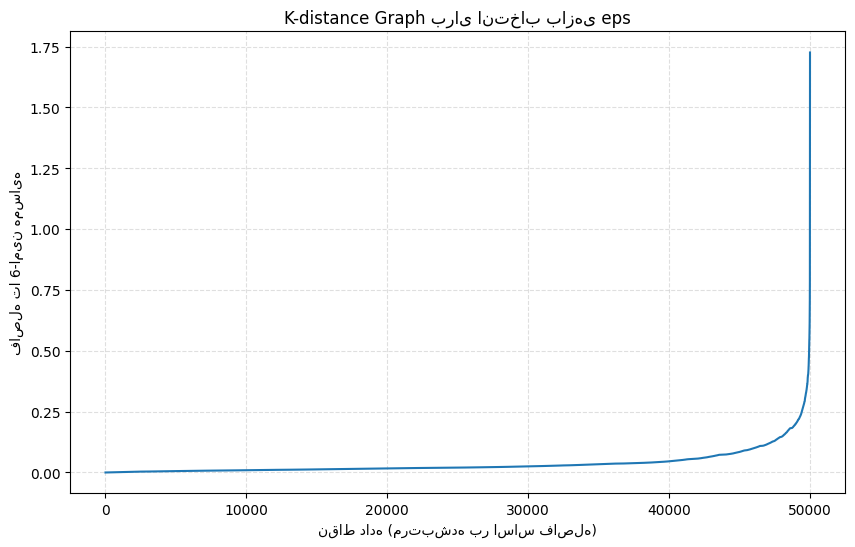

In [27]:
# قانون تجربی رایج برای min_samples اولیه: تقریباً ۲ برابر تعداد ویژگی‌ها
min_samples_guess = 2 * X_scaled.shape[1]  # اینجا = 6

neighbors = NearestNeighbors(n_neighbors=min_samples_guess)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 6))
plt.plot(k_distances)
plt.xlabel('نقاط داده (مرتب‌شده بر اساس فاصله)')
plt.ylabel(f'فاصله تا {min_samples_guess}-امین همسایه')
plt.title('K-distance Graph برای انتخاب بازه‌ی eps')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [31]:
search_sample = sample_df.sample(n=15000, random_state=42)
X_search = scaler.transform(search_sample[dbscan_features])
print(X_search.shape)

(15000, 3)


In [33]:
# تمام ترکیب‌هایی که ۳ خوشه تولید کردن رو ببینیم، صرف‌نظر از شرط تعادل
three_cluster_rows = results_df[results_df['n_clusters'] == 3].sort_values('smallest_cluster_ratio', ascending=False)
print(f"تعداد کل ترکیب‌هایی که 3 خوشه دادن: {len(three_cluster_rows)}")
three_cluster_rows.head(20)

تعداد کل ترکیب‌هایی که 3 خوشه دادن: 5


,eps,min_samples,n_clusters,noise_ratio,smallest_cluster_ratio
39,0.55,60,3,0.035,0.008
37,0.55,20,3,0.010,0.007
42,0.60,40,3,0.018,0.006
32,0.50,10,3,0.005,0.001
40,0.60,10,3,0.002,0.001


In [34]:
best_labels = DBSCAN(eps=0.55, min_samples=20, n_jobs=-1).fit_predict(X_search)
search_sample_copy = search_sample.copy()
search_sample_copy['Cluster'] = best_labels

for c in sorted(search_sample_copy['Cluster'].unique()):
    sub = search_sample_copy[search_sample_copy['Cluster'] == c]
    print(f"--- Cluster {c} (تعداد: {len(sub)}) ---")
    print("شهرهای غالب:", sub['city_slug'].value_counts().head(3).to_dict())
    print("میانگین قیمت:", sub['price_value'].mean())
    print()

--- Cluster -1 (تعداد: 144) ---
شهرهای غالب: {'kish': 34, 'chabahar': 11, 'yazd': 9}
میانگین قیمت: 7234914421.986111

--- Cluster 0 (تعداد: 14400) ---
شهرهای غالب: {'tehran': 2679, 'mashhad': 845, 'karaj': 836}
میانگین قیمت: 3414430077.174097

--- Cluster 1 (تعداد: 350) ---
شهرهای غالب: {'kerman': 121, 'bandar-abbas': 117, 'sirjan': 30}
میانگین قیمت: 2489856067.36

--- Cluster 2 (تعداد: 106) ---
شهرهای غالب: {'zahedan': 75, 'Iranshahr': 15, 'zabol': 7}
میانگین قیمت: 1512657973.3773584



In [35]:
eps_final = 0.55
min_samples_final = 20

dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples_final, n_jobs=-1)
sample_df['Cluster'] = dbscan_final.fit_predict(X_scaled)

print(sample_df['Cluster'].value_counts())

Cluster
 0    49514
 1      373
-1       74
 2       39
Name: count, dtype: int64


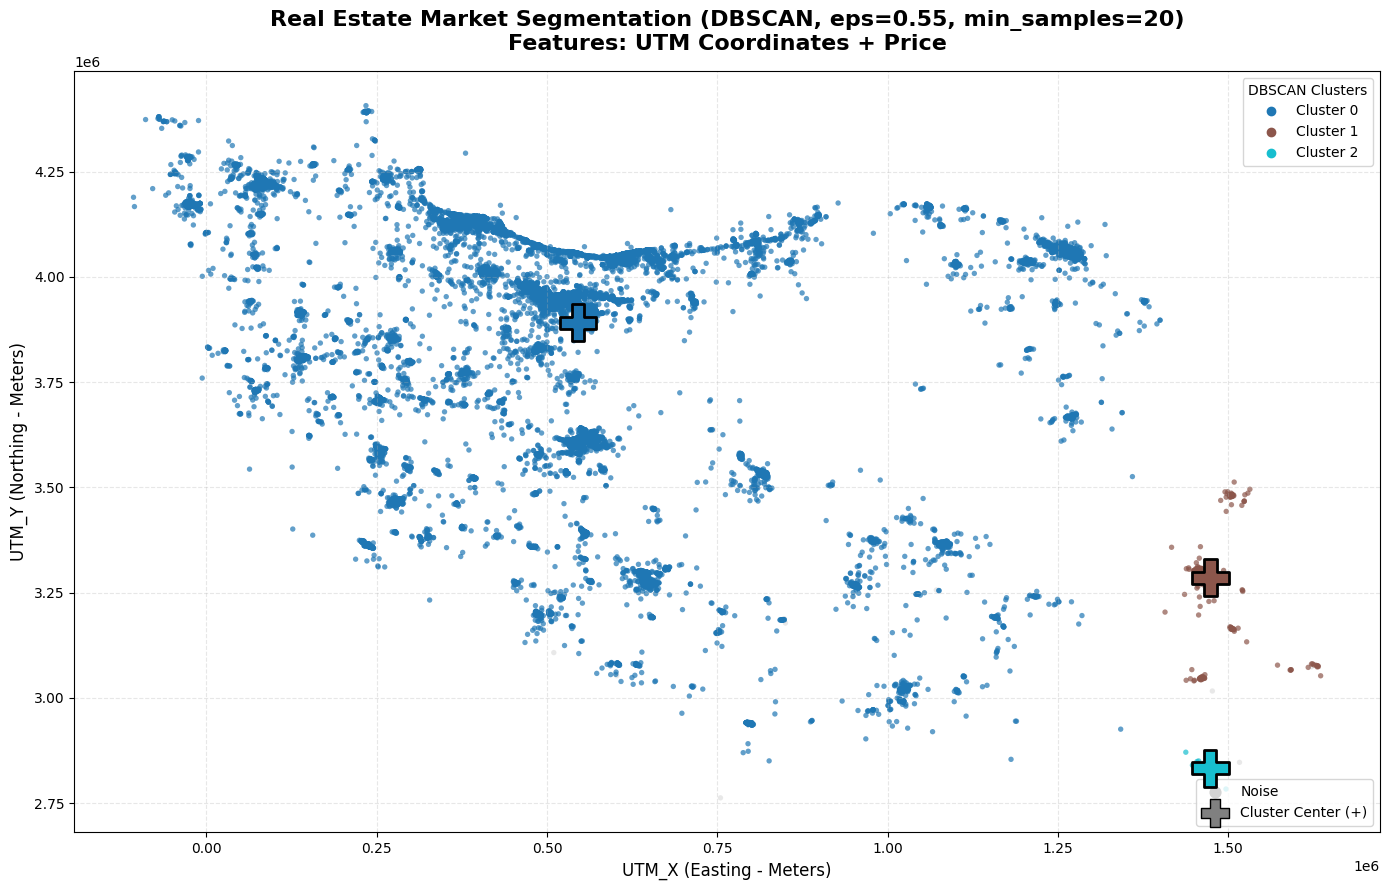

In [36]:
cluster_ids = sorted([c for c in sample_df['Cluster'].unique() if c != -1])
centroids = sample_df[sample_df['Cluster'] != -1].groupby('Cluster')[['UTM_X', 'UTM_Y']].mean()

fig, ax = plt.subplots(figsize=(14, 9))

noise_mask = sample_df['Cluster'] == -1
ax.scatter(
    sample_df.loc[noise_mask, 'UTM_X'],
    sample_df.loc[noise_mask, 'UTM_Y'],
    c='lightgray', alpha=0.5, s=15, edgecolors='none'
)

scatter = ax.scatter(
    sample_df.loc[~noise_mask, 'UTM_X'],
    sample_df.loc[~noise_mask, 'UTM_Y'],
    c=sample_df.loc[~noise_mask, 'Cluster'],
    cmap='tab10', alpha=0.7, s=15, edgecolors='none',
    vmin=0, vmax=max(cluster_ids)
)

ax.scatter(
    centroids['UTM_X'], centroids['UTM_Y'],
    c=cluster_ids, cmap='tab10', vmin=0, vmax=max(cluster_ids),
    marker='P', s=700, edgecolors='black', linewidths=2, zorder=10
)

handles, _ = scatter.legend_elements(prop="colors", alpha=1)
legend_clusters = ax.legend(
    handles, [f"Cluster {i}" for i in cluster_ids],
    loc="upper right", title="DBSCAN Clusters", fontsize=10
)
ax.add_artist(legend_clusters)
ax.scatter([], [], c='lightgray', s=60, label='Noise')
ax.scatter([], [], c='gray', marker='P', s=400, edgecolors='black', label='Cluster Center (+)')
ax.legend(loc="lower right")

ax.set_title(
    f'Real Estate Market Segmentation (DBSCAN, eps={eps_final}, min_samples={min_samples_final})\n'
    f'Features: UTM Coordinates + Price',
    fontsize=16, fontweight='bold', pad=15
)
ax.set_xlabel('UTM_X (Easting - Meters)', fontsize=12)
ax.set_ylabel('UTM_Y (Northing - Meters)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

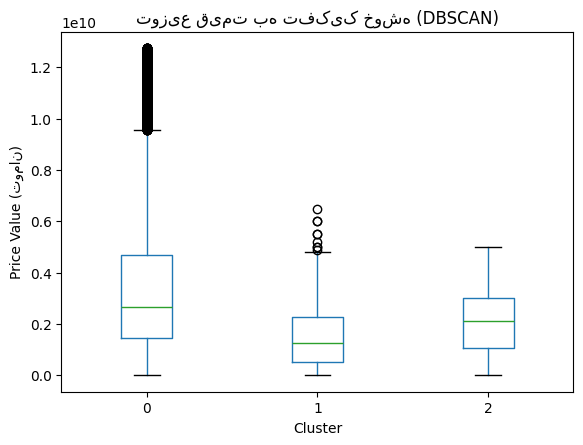

In [37]:
plt.figure(figsize=(10, 6))
plot_df = sample_df[sample_df['Cluster'] != -1]
plot_df.boxplot(column='price_value', by='Cluster', grid=False)
plt.title('توزیع قیمت به تفکیک خوشه (DBSCAN)')
plt.suptitle('')
plt.xlabel('Cluster')
plt.ylabel('Price Value (تومان)')
plt.show()

In [32]:
results = []
eps_candidates = np.arange(0.10, 0.61, 0.05)
min_samples_candidates = [10, 20, 40, 60]

for eps in eps_candidates:
    for ms in min_samples_candidates:
        labels = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(X_search)
        unique, counts = np.unique(labels, return_counts=True)
        cluster_counts = {u: c for u, c in zip(unique, counts) if u != -1}
        n_clusters = len(cluster_counts)
        noise_ratio = np.mean(labels == -1)

        if n_clusters == 3:
            sizes = sorted(cluster_counts.values())
            smallest_ratio = sizes[0] / sum(sizes)
        else:
            smallest_ratio = 0

        results.append({'eps': round(eps, 2), 'min_samples': ms,
                         'n_clusters': n_clusters, 'noise_ratio': round(noise_ratio, 3),
                         'smallest_cluster_ratio': round(smallest_ratio, 3)})

results_df = pd.DataFrame(results)

candidates = results_df[
    (results_df['n_clusters'] == 3) &
    (results_df['noise_ratio'] < 0.20) &
    (results_df['smallest_cluster_ratio'] > 0.10)
]
candidates = candidates.sort_values('smallest_cluster_ratio', ascending=False)
print(f"تعداد پیکربندی‌های متعادل: {len(candidates)}")
candidates.head(15)

تعداد پیکربندی‌های متعادل: 0


,eps,min_samples,n_clusters,noise_ratio,smallest_cluster_ratio


In [ ]:
best = candidates.iloc[0]
eps_final = float(best['eps'])
min_samples_final = int(best['min_samples'])

print(f"eps نهایی: {eps_final}   |   min_samples نهایی: {min_samples_final}")

dbscan_final = DBSCAN(eps=eps_final, min_samples=min_samples_final, n_jobs=-1)
sample_df['Cluster'] = dbscan_final.fit_predict(X_scaled)

print(sample_df['Cluster'].value_counts())

eps نهایی: 0.5   |   min_samples نهایی: 10
Cluster
 0    49535
 1      373
-1       51
 2       41
Name: count, dtype: int64
